In [2]:
import pandas as pd

df = pd.read_csv(
    "assurex_nigeria_warranty_claims_v2.csv",
    keep_default_na=False,
    na_values=[""]
)

df.head()

,claim_id,region_zone,state,city,customer_type,seller_type,purchase_channel,product_category,brand,model_family,...,reporting_delay_days,policy_reporting_deadline_days,statutory_3_month_window,requested_remedy,claim_amount_ngn,document_completeness_score,claim_channel,claim_class,split,provenance_ref
0,NG-WC-00001,South East,Abia,Aba,Home Office,Authorized Dealer,Physical Store,Bluetooth Speaker,Oraimo,Boom series,...,42,30,False,Repair,5000,0.5,Authorized service centre,Manual Review Required,validation,PV-00001
1,NG-WC-00974,North East,Taraba,Jalingo,Individual,Authorized Dealer,Physical Store,Refrigerator,LG,Inverter Refrigerator,...,40,14,False,Repair,949000,1.0,Online support form,Likely Invalid,validation,PV-00974
2,NG-WC-01945,North Central,FCT,Abuja,Individual,Authorized Dealer,Physical Store,Solar Inverter,Felicity Solar,IVPS / IVGM selected series,...,0,21,False,Repair or replacement,2947000,1.0,Marketplace support portal,Likely Valid,test,PV-01945
3,NG-WC-00488,South East,Abia,Aba,Home Office,Online Marketplace,Online,Tubular Battery,Luminous,Inverlast / NRGT,...,0,14,False,Replacement,321000,1.0,Online support form,Likely Valid,validation,PV-00488
4,NG-WC-01018,North West,Kaduna,Zaria,Individual,Jumia Mall / Official Store,Online,Smart Watch,Oraimo,Watch series,...,27,21,True,Replacement,117000,1.0,Authorized service centre,Likely Invalid,validation,PV-01018


In [3]:
print(df.shape)
print(df["claim_class"].value_counts())

display(pd.crosstab(df["split"], df["claim_class"]))
display(df.isna().sum().sort_values(ascending=False).head(10))

assert df["claim_id"].is_unique

(2400, 57)
claim_class
Manual Review Required    800
Likely Invalid            800
Likely Valid              800
Name: count, dtype: int64


claim_class,Likely Invalid,Likely Valid,Manual Review Required
split,,,
test,120,120,120
train,560,560,560
validation,120,120,120


claim_id                    0
receipt_available           0
warranty_card_available     0
serial_or_imei_available    0
serial_evidence_type        0
serial_match_status         0
product_photo_available     0
repair_report_available     0
fault_evidence_type         0
prior_repairs               0
dtype: int64

In [4]:
numeric_features = [
    "warranty_months",
    "days_from_purchase_to_claim",
    "reporting_delay_days",
    "policy_reporting_deadline_days",
    "prior_repairs",
]

categorical_features = [
    "product_category",
    "policy_code",
    "warranty_start_basis",
    "official_channel_status",
    "fault_category",
    "damage_cause",
    "purchase_document_type",
    "serial_match_status",
    "fault_evidence_type",
]

boolean_features = [
    "receipt_available",
    "warranty_card_available",
    "serial_or_imei_available",
    "product_photo_available",
    "repair_report_available",
    "prior_repair_authorized",
    "tamper_flag",
]

features = numeric_features + categorical_features + boolean_features
target = "claim_class"

In [5]:
train = df.loc[df["split"] == "train"].copy()
validation = df.loc[df["split"] == "validation"].copy()
test = df.loc[df["split"] == "test"].copy()

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

print(X_train.shape, X_val.shape, X_test.shape)

(1680, 21) (360, 21) (360, 21)


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
    ("boolean", "passthrough", boolean_features),
])

In [8]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
}

trained_models = {}
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_val)

    trained_models[name] = pipeline

    results.append({
        "model": name,
        "validation_accuracy": accuracy_score(y_val, predictions),
        "validation_macro_f1": f1_score(
            y_val, predictions, average="macro"
        ),
    })

results_df = pd.DataFrame(results).sort_values(
    "validation_macro_f1", ascending=False
)

display(results_df)

,model,validation_accuracy,validation_macro_f1
2,Gradient Boosting,0.966667,0.966508
1,Random Forest,0.963889,0.963723
0,Logistic Regression,0.930556,0.930694


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in trained_models.items():
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=1,
    )
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression: 0.892 ± 0.020
Random Forest: 0.924 ± 0.019
Gradient Boosting: 0.950 ± 0.011


Selected model: Gradient Boosting
Test accuracy: 0.9527777777777777
                        precision    recall  f1-score   support

        Likely Invalid       0.97      0.96      0.96       120
          Likely Valid       0.92      0.98      0.95       120
Manual Review Required       0.97      0.92      0.94       120

              accuracy                           0.95       360
             macro avg       0.95      0.95      0.95       360
          weighted avg       0.95      0.95      0.95       360



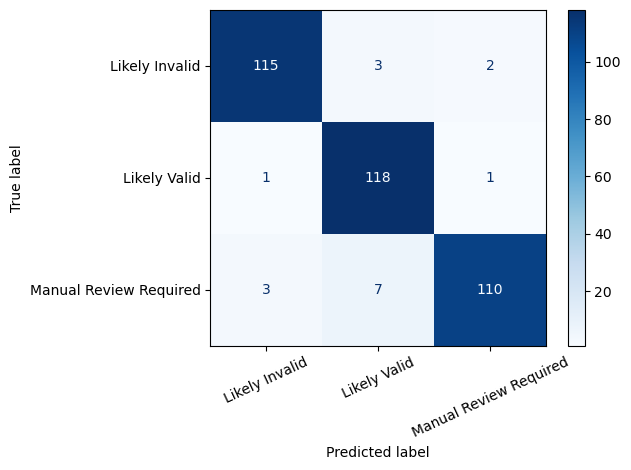

In [10]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

best_name = results_df.iloc[0]["model"]
best_model = trained_models[best_name]

test_predictions = best_model.predict(X_test)

print("Selected model:", best_name)
print("Test accuracy:", accuracy_score(y_test, test_predictions))
print(classification_report(y_test, test_predictions, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    xticks_rotation=25,
    cmap="Blues",
)
plt.tight_layout()
plt.show()

In [11]:
sample = X_test.iloc[[0]]

print("Prediction:", best_model.predict(sample)[0])

probabilities = pd.DataFrame(
    best_model.predict_proba(sample),
    columns=best_model.classes_,
)

display(probabilities)

Prediction: Likely Valid


,Likely Invalid,Likely Valid,Manual Review Required
0,0.00617,0.970219,0.023611


In [12]:
import joblib
from pathlib import Path

Path("model").mkdir(exist_ok=True)

joblib.dump(
    best_model,
    "model/assurex_claim_pipeline.joblib"
)

['model/assurex_claim_pipeline.joblib']